In [1]:
import warnings
warnings.filterwarnings("ignore")
import os
os.environ['TE_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

In [2]:
!pip install optuna

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import csv
import seaborn as sns
import optuna

import re
import string

from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import precision_recall_fscore_support, average_precision_score, accuracy_score, \
                            precision_score, recall_score, f1_score, classification_report, precision_recall_curve

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.layers import Embedding, Dense, LSTM, Bidirectional, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.backend import clear_session
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import load_model, Sequential

Loading the dataset

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
df = pd.read_csv('../data/Filter_Toxic_Comments_dataset.csv')

# Dataset observation

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   comment_text   159571 non-null  object
 1   toxic          159571 non-null  int64 
 2   severe_toxic   159571 non-null  int64 
 3   obscene        159571 non-null  int64 
 4   threat         159571 non-null  int64 
 5   insult         159571 non-null  int64 
 6   identity_hate  159571 non-null  int64 
 7   sum_injurious  159571 non-null  int64 
dtypes: int64(7), object(1)
memory usage: 9.7+ MB


The dataset does not present any problems

In [7]:
df.head(10)

,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,sum_injurious
0,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0,0
1,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0,0
2,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0,0
3,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0,0
4,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0,0
5,"""\n\nCongratulations from me as well, use the ...",0,0,0,0,0,0,0
6,COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK,1,1,1,0,1,0,4
7,Your vandalism to the Matt Shirvington article...,0,0,0,0,0,0,0
8,Sorry if the word 'nonsense' was offensive to ...,0,0,0,0,0,0,0
9,alignment on this subject and which are contra...,0,0,0,0,0,0,0


The dataset is composed of 8 columns: there is the column of comments to be analyzed, the columns, from 1-6, which label in binary which insult favor the comment has, and finally a recap column.

Let's see how many of the comments can be classified as negative.

In [8]:
print(f"\033[92mNegative comments in the dataset: {(df['sum_injurious'] != 0).sum()}\033[0m")

Negative comments in the dataset: 16225


The dataset appears highly unbalanced. We also see how the categories are distributed among the negative comments

In [9]:
print(f'\033[92m{df.loc[:, "toxic":"identity_hate"].sum()}\033[0m')

toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64


there is also an imbalance among the target labels.

# Data Cleaning

Let's define a function that cleans up the text

In [10]:
def clean(text):
  if not isinstance(text, str):
    return ""
  # Lowercase
  text = text.lower()
  # Remove URLs
  text = re.sub(r'http\S+|www\S+|https\S+', '', text)
  # Remove HTML tags
  text = re.sub(r'<.*?>', '', text)
  # Remove mentions (@username)
  text = re.sub(r'@\w+', '', text)
  # Remove weird symbols but keep punctuation like ! ? . ,
  text = re.sub(r"[^a-zA-Z0-9.,!?\'\"\s]", " ", text)
  # Replace multiple spaces
  text = re.sub(r'\s+', ' ', text).strip()

  return text

In [11]:
df['comment_text'] = [clean(c) for c in df['comment_text']]

# Models

The adopted modeling pipeline consists of two sequential models. The first is a binary classifier that determines whether a comment contains hate speech (0 for neutral content, 1 for offensive or discriminatory content). Only if the prediction is positive is the comment passed to a second model, responsible for classifying the specific type of hate speech among the predicted categories.

Let's proceed with the first model, called *Binary Hate Model*, which implements a binary classification aimed at distinguishing between neutral comments and comments containing hate speech.

## Binary Hate Model



Comments are labelled as hateful when the value of the `sum_injurious` column is greater than or equal to 1. Starting from this rule, I generate a new binary target variable, `has_hate`, which will serve as the label for the Binary Hate Model

In [12]:
df['has_hate'] = df[['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']].any(axis = 1).astype(int)
df.head(5)

,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,sum_injurious,has_hate
0,explanation why the edits made under my userna...,0,0,0,0,0,0,0,0
1,d'aww! he matches this background colour i'm s...,0,0,0,0,0,0,0,0
2,"hey man, i'm really not trying to edit war. it...",0,0,0,0,0,0,0,0
3,""" more i can't make any real suggestions on im...",0,0,0,0,0,0,0,0
4,"you, sir, are my hero. any chance you remember...",0,0,0,0,0,0,0,0


I then split the dataset into the feature matrix and the target vector, separating the textual input from the binary label `has_hate`

In [13]:
x = df.comment_text.values
y_binary_hate = df.loc[:, 'has_hate']
print(f'\033[92mComments with hating: {100*y_binary_hate.sum()/len(y_binary_hate):.1f}%\033[0m')
print(f'\033[92m{x.shape} {y_binary_hate.shape}\033[0m')

Comments with hating: 10.2%
(159571,) (159571,)


Finally, the dataset is split into training and testing sets to ensure a proper evaluation of the model’s generalization performance

In [14]:
x_train_binary_hate, x_test_binary_hate, y_train_binary_hate, y_test_binary_hate = train_test_split(x, y_binary_hate, test_size = 0.2, random_state = 1, stratify = y_binary_hate, shuffle = True)

Before training the model, the text data must be converted into a numerical representation. I therefore fit a `Tokenizer` on the training set, limit the vocabulary size to the most frequent 10,000 tokens, and transform each comment into a sequence of integer indices. I also compute the 95th percentile of sequence lengths to define a suitable maximum length for padding.

In [15]:
num_words_bh = 10000

tokenizer_binary_hate = Tokenizer(num_words=num_words_bh, oov_token="<OOV>")
tokenizer_binary_hate.fit_on_texts(x_train_binary_hate)

train_sequences_binary_hate = tokenizer_binary_hate.texts_to_sequences(x_train_binary_hate)
test_sequences_binary_hate = tokenizer_binary_hate.texts_to_sequences(x_test_binary_hate)

max_len_binary_hate = int(np.percentile([len(seq) for seq in train_sequences_binary_hate], 95))
print(f'\033[92mMaximum train sequence length: {max_len_binary_hate}\033[0m')

vocabulary_size_binary_hate = num_words_bh + 1
print(f'\033[92mVocabulary size: {vocabulary_size_binary_hate}\033[0m')

Maximum train sequence length: 232
Vocabulary size: 10001


To standardize the input shape for the model, I pad all tokenized sequences to the predefined maximum length. Padding guarantees consistent dimensionality across samples and enables efficient batch processing

In [16]:
padded_train_binary_hate_sequences = pad_sequences(sequences = train_sequences_binary_hate, maxlen = max_len_binary_hate)
padded_test_binary_hate_sequences = pad_sequences(sequences = test_sequences_binary_hate, maxlen = max_len_binary_hate)

We expect the paddate sequences to be matrices (n_samples $\times$ max_len)

In [17]:
print(f'\033[92mTrain set: {padded_train_binary_hate_sequences.shape}\033[0m')
print(f'\033[92mTest set: {padded_test_binary_hate_sequences.shape}\033[0m')

Train set: (127656, 232)
Test set: (31915, 232)


We construct the Binary Hate Model with a simple architecture consisting of a single BiLSTM layer followed by a dense output layer. Extensive experimentation showed that more complex architectures did not improve performance and only increased computational cost

In [18]:
def binary_hate_model(vocabulary_size, max_len, dropout, optimizer, loss, metrics,
                      lstm_units=32, embedding_dim=64, dense_units=16):

  model = Sequential()
  model.add(Embedding(input_dim = vocabulary_size, output_dim = embedding_dim, input_length = max_len))

  model.add(Bidirectional(LSTM(lstm_units, return_sequences=False, activation='tanh')))
  model.add(BatchNormalization())
  model.add(Dropout(dropout))

  model.add(Dense(dense_units, activation='relu'))
  model.add(BatchNormalization())
  model.add(Dropout(dropout))

  model.add(Dense(units = 1, activation = 'sigmoid'))
  model.build(input_shape = (None, max_len))

  model.compile(optimizer = optimizer,
                loss = loss,
                metrics = metrics)

  return model

To further improve the model, we employ Optuna for hyperparameter optimization, allowing us to automatically search for the best combination of parameters such as
- Embedding units
- LSTM units
- Dropout rate
- Learning rate
- Dense layer size
- Batch size

But first it is useful to define some auxiliary functions for the optimization process and for training in general, such as:

1. Callbacks for optimization, such as early stopping and learning-rate scheduling, to ensure stable convergence and avoid unnecessary computation.

2. A custom F1-Score metric, since TensorFlow does not provide a built-in token-level or sequence-level F1 and accuracy alone is not informative for imbalanced hate-speech data.

3. Class weights, computed from the training distribution, to mitigate class imbalance during optimization.

In [19]:
def callback_binary_hate_optuna():

  reduce_learning_rate = ReduceLROnPlateau(monitor = 'val_loss',
                                           factor = 0.8,
                                           patience = 2,
                                           min_lr = 1e-6,
                                           verbose = 0)

  early_stop = EarlyStopping(monitor = 'val_loss',
                             patience = 3,
                             restore_best_weights = True,
                             verbose = 1)

  return early_stop, reduce_learning_rate


class F1Score(tf.keras.metrics.Metric):
  def __init__(self, name='f1', **kwargs):
    super(F1Score, self).__init__(name=name, **kwargs)
    self.precision = tf.keras.metrics.Precision()
    self.recall = tf.keras.metrics.Recall()

  def update_state(self, y_true, y_pred, sample_weight=None):
    self.precision.update_state(y_true, y_pred, sample_weight)
    self.recall.update_state(y_true, y_pred, sample_weight)

  def result(self):
    p = self.precision.result()
    r = self.recall.result()
    return 2 * (p * r) / (p + r + tf.keras.backend.epsilon())

  def reset_states(self):
    self.precision.reset_states()
    self.recall.reset_states()



def class_weights_hate(y):

  class_weights_hate = class_weight.compute_class_weight(class_weight = 'balanced',
                                                         classes = np.unique(y),
                                                         y = y)

  class_weights_hate = dict(enumerate(class_weights_hate))

  return class_weights_hate

To perform hyperparameter optimization, an Optuna objective function is defined. Each trial samples a set of candidate hyperparameters, constructs a model accordingly, trains it, and returns a scalar objective to be minimized

In [20]:
def objective_bh(trial):

  # HYPERPARAMETERS
  embedding_dim = trial.suggest_categorical("embedding_dim", [128, 256, 512])
  lstm_units = trial.suggest_categorical("lstm_units", [128, 256, 384])
  dropout = trial.suggest_float("dropout", 0.1, 0.5)
  dense_units = trial.suggest_categorical("dense_units", [8, 16, 32])
  learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True)
  batch_size = trial.suggest_categorical("batch_size", [256, 512, 1025])


  if lstm_units > embedding_dim:
    raise optuna.TrialPruned("LSTM units must be < embedding dim")
  elif dense_units >= lstm_units:
    raise optuna.TrialPruned("Dense units must be <= LSTM units")

  # OPTIMIZER
  optimizer = tf.keras.optimizers.AdamW(learning_rate=learning_rate)

  # MODEL
  model = binary_hate_model(
      vocabulary_size = vocabulary_size_binary_hate,
      max_len = max_len_binary_hate,
      dropout = dropout,
      lstm_units = lstm_units,
      embedding_dim = embedding_dim,
      dense_units = dense_units,
      optimizer = optimizer,
      loss="binary_crossentropy",
      metrics = [
          'accuracy',
          tf.keras.metrics.Precision(name = 'precision'),
          tf.keras.metrics.Recall(name = 'recall'),
          F1Score(name='f1')
          ]
      )

  # FIT
  history = model.fit(
      padded_train_binary_hate_sequences,
      y_train_binary_hate,
      validation_split = 0.2,
      epochs=10,
      batch_size=batch_size,
      class_weight = class_weights_hate(y_train_binary_hate),
      callbacks=[callback_binary_hate_optuna()]
  )

  # PREDICTION AND EVALUATION
  y_pred_test = model.predict(padded_test_binary_hate_sequences)
  f1_test = f1_score(y_test_binary_hate, y_pred_test>=0.5)
  print(f"Trial {trial.number} — F1 test (not used for tuning): {f1_test:.4f}")

  val_loss = min(history.history["val_loss"])

  return val_loss

Once the objective function is defined, an Optuna study is instantiated to orchestrate the hyperparameter search. The study is configured to minimize the validation loss returned by each trial.

The search is executed over a fixed number of trials. After completion, the study exposes the best-performing hyperparameter configuration as well as the corresponding objective value

In [21]:
study_bh = optuna.create_study(
        direction="minimize",
        study_name="binary_hate_opt",
        sampler=optuna.samplers.TPESampler(seed=42)
    )

study_bh.optimize(objective_bh, n_trials=10)

print(study_bh.best_params)
print(f"\033[92mBest val_loss Score: {study_bh.best_value:.4f}\033[0m")

[I 2025-12-12 08:39:57,744] A new study created in memory with name: binary_hate_opt


Epoch 1/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 25s 43ms/step - accuracy: 0.4628 - f1: 0.2017 - loss: 0.8872 - precision: 0.1193 - recall: 0.6531 - val_accuracy: 0.1038 - val_f1: 0.1808 - val_loss: 1.1789 - val_precision: 0.0994 - val_recall: 0.9992 - learning_rate: 1.2088e-05
Epoch 2/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 17s 42ms/step - accuracy: 0.5307 - f1: 0.2630 - loss: 0.6535 - precision: 0.1568 - recall: 0.8150 - val_accuracy: 0.6164 - val_f1: 0.2949 - val_loss: 0.6497 - val_precision: 0.1802 - val_recall: 0.8104 - learning_rate: 1.2088e-05
Epoch 3/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 17s 42ms/step - accuracy: 0.5584 - f1: 0.2835 - loss: 0.5925 - precision: 0.1701 - recall: 0.8511 - val_accuracy: 0.7343 - val_f1: 0.3652 - val_loss: 0.5140 - val_precision: 0.2391 - val_recall: 0.7721 - learning_rate: 1.2088e-05
Epoch 4/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 17s 42ms/step - accuracy: 0.5858 - f1: 0.3041 - loss: 0.5451 - precision: 0.1836 - recall: 0.8843 - val_accuracy: 0.7530 - val_f1: 0.3911 - val_loss: 

[I 2025-12-12 08:43:01,669] Trial 0 finished with value: 0.4307524263858795 and parameters: {'embedding_dim': 256, 'lstm_units': 128, 'dropout': 0.12323344486727979, 'dense_units': 8, 'learning_rate': 1.2087541473056957e-05, 'batch_size': 256}. Best is trial 0 with value: 0.4307524263858795.


Trial 0 — F1 test (not used for tuning): 0.4914
Epoch 1/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 27s 58ms/step - accuracy: 0.7062 - f1: 0.3760 - loss: 0.5109 - precision: 0.2449 - recall: 0.8334 - val_accuracy: 0.9532 - val_f1: 0.7556 - val_loss: 0.2261 - val_precision: 0.7812 - val_recall: 0.7317 - learning_rate: 6.6724e-04
Epoch 2/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 22s 56ms/step - accuracy: 0.9175 - f1: 0.6940 - loss: 0.2265 - precision: 0.5584 - recall: 0.9167 - val_accuracy: 0.9228 - val_f1: 0.6939 - val_loss: 0.2288 - val_precision: 0.5712 - val_recall: 0.8837 - learning_rate: 6.6724e-04
Epoch 3/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 22s 56ms/step - accuracy: 0.9341 - f1: 0.7451 - loss: 0.1734 - precision: 0.6177 - recall: 0.9388 - val_accuracy: 0.9045 - val_f1: 0.6548 - val_loss: 0.2581 - val_precision: 0.5098 - val_recall: 0.9149 - learning_rate: 6.6724e-04
Epoch 4/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 22s 56ms/step - accuracy: 0.9466 - f1: 0.7874 - loss: 0.1320 - precision: 0.6656 - recall: 0.9651 - va

[I 2025-12-12 08:45:50,094] Trial 1 finished with value: 0.18069852888584137 and parameters: {'embedding_dim': 512, 'lstm_units': 128, 'dropout': 0.34474115788895177, 'dense_units': 32, 'learning_rate': 0.0006672367170464204, 'batch_size': 256}. Best is trial 1 with value: 0.18069852888584137.


...

Trial 7 — F1 test (not used for tuning): 0.7603
Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 105ms/step - accuracy: 0.5367 - f1: 0.2270 - loss: 0.8265 - precision: 0.1368 - recall: 0.6662 - val_accuracy: 0.9017 - val_f1: 0.0172 - val_loss: 0.6321 - val_precision: 0.8148 - val_recall: 0.0087 - learning_rate: 1.8707e-04
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - accuracy: 0.6753 - f1: 0.3666 - loss: 0.4988 - precision: 0.2295 - recall: 0.9115 - val_accuracy: 0.9089 - val_f1: 0.1549 - val_loss: 0.5042 - val_precision: 0.9509 - val_recall: 0.0843 - learning_rate: 1.8707e-04
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - accuracy: 0.7755 - f1: 0.4650 - loss: 0.3863 - precision: 0.3091 - recall: 0.9386 - val_accuracy: 0.9359 - val_f1: 0.5384 - val_loss: 0.3907 - val_precision: 0.9381 - val_recall: 0.3775 - learning_rate: 1.8707e-04
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - accuracy: 0.8383 - f1: 0.5462 - loss: 0.3108 - precision: 0.3836 - recall: 0.9491 - v

[I 2025-12-12 09:02:41,870] Trial 8 finished with value: 0.1558745950460434 and parameters: {'embedding_dim': 128, 'lstm_units': 128, 'dropout': 0.45702359939599113, 'dense_units': 32, 'learning_rate': 0.0001870742013766025, 'batch_size': 1025}. Best is trial 5 with value: 0.15329061448574066.


Trial 8 — F1 test (not used for tuning): 0.7717
Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 132ms/step - accuracy: 0.7144 - f1: 0.3809 - loss: 0.5120 - precision: 0.2496 - recall: 0.8154 - val_accuracy: 0.9217 - val_f1: 0.3491 - val_loss: 0.3060 - val_precision: 0.9853 - val_recall: 0.2121 - learning_rate: 0.0012
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 126ms/step - accuracy: 0.9139 - f1: 0.6864 - loss: 0.2342 - precision: 0.5448 - recall: 0.9283 - val_accuracy: 0.9445 - val_f1: 0.6153 - val_loss: 0.2009 - val_precision: 0.9784 - val_recall: 0.4488 - learning_rate: 0.0012
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 126ms/step - accuracy: 0.9414 - f1: 0.7701 - loss: 0.1690 - precision: 0.6493 - recall: 0.9461 - val_accuracy: 0.9545 - val_f1: 0.7180 - val_loss: 0.1503 - val_precision: 0.9296 - val_recall: 0.5849 - learning_rate: 0.0012
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 125ms/step - accuracy: 0.9545 - f1: 0.8130 - loss: 0.1296 - precision: 0.7034 - recall: 0.9633 - val_accura

[I 2025-12-12 09:04:22,421] Trial 9 finished with value: 0.13631309568881989 and parameters: {'embedding_dim': 256, 'lstm_units': 128, 'dropout': 0.14794614693347313, 'dense_units': 16, 'learning_rate': 0.0011889469769530464, 'batch_size': 1025}. Best is trial 9 with value: 0.13631309568881989.


Trial 9 — F1 test (not used for tuning): 0.7842
{'embedding_dim': 256, 'lstm_units': 128, 'dropout': 0.14794614693347313, 'dense_units': 16, 'learning_rate': 0.0011889469769530464, 'batch_size': 1025}
Best val_loss Score: 0.1363


After identifying the best hyperparameters through Optuna, the model is re-instantiated using the optimal configuration. This ensures that the final training phase is performed with the most effective architecture and learning setup discovered during the search. The model is then compiled with the selected optimizer and evaluation metrics and its structure is displayed for verification

In [22]:
clear_session()
model_hate_binary = binary_hate_model(vocabulary_size = vocabulary_size_binary_hate,
                                      max_len = max_len_binary_hate,
                                      dropout = study_bh.best_params['dropout'],
                                      lstm_units = study_bh.best_params['lstm_units'],
                                      embedding_dim = study_bh.best_params['embedding_dim'],
                                      dense_units = study_bh.best_params['dense_units'],
                                      optimizer = tf.keras.optimizers.AdamW(learning_rate = study_bh.best_params['learning_rate']),
                                      loss = 'binary_crossentropy',
                                      metrics = ['accuracy',
                                                 tf.keras.metrics.AUC(name = 'auc', multi_label=False),
                                                 tf.keras.metrics.Precision(name = 'precision'),
                                                 tf.keras.metrics.Recall(name = 'recall'),
                                                 F1Score(name='f1')])
model_hate_binary.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 232, 256)       │     2,560,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │         4,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,959,713 (11.29 MB)

 Trainable params: 2,959,169 (11.29 MB)

 Non-trainable params: 544 (2.12 KB)

Now define the callback for training

In [23]:
def callback_binary_hate():

  reduce_learning_rate = ReduceLROnPlateau(monitor = 'val_loss',
                                           factor = 0.8,
                                           patience = 3,
                                           min_lr = 1e-6,
                                           verbose = 0)

  early_stop = EarlyStopping(monitor = 'val_loss',
                             patience = 7,
                             restore_best_weights = True,
                             verbose = 1)

  return early_stop, reduce_learning_rate

The model is trained for up to 100 epochs with a validation split of 0.2, using class weighting to compensate for label imbalance. Early stopping is employed via the callback to prevent overfitting and retain the best-performing weights

In [24]:
history_hate_binary = model_hate_binary.fit(padded_train_binary_hate_sequences,
                                            y_train_binary_hate,
                                            epochs = 100,
                                            validation_split = 0.2,
                                            batch_size = study_bh.best_params['batch_size'],
                                            class_weight = class_weights_hate(y_train_binary_hate),
                                            callbacks = [callback_binary_hate()])

Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 135ms/step - accuracy: 0.6891 - auc: 0.8394 - f1: 0.3644 - loss: 0.5138 - precision: 0.2348 - recall: 0.8330 - val_accuracy: 0.9337 - val_auc: 0.9586 - val_f1: 0.5113 - val_loss: 0.3605 - val_precision: 0.9465 - val_recall: 0.3502 - learning_rate: 0.0012
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 126ms/step - accuracy: 0.9158 - auc: 0.9747 - f1: 0.6970 - loss: 0.2267 - precision: 0.5579 - recall: 0.9285 - val_accuracy: 0.9457 - val_auc: 0.9667 - val_f1: 0.6282 - val_loss: 0.2041 - val_precision: 0.9750 - val_recall: 0.4634 - learning_rate: 0.0012
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 127ms/step - accuracy: 0.9416 - auc: 0.9864 - f1: 0.7697 - loss: 0.1606 - precision: 0.6474 - recall: 0.9491 - val_accuracy: 0.9533 - val_auc: 0.9609 - val_f1: 0.7033 - val_loss: 0.1500 - val_precision: 0.9465 - val_recall: 0.5596 - learning_rate: 0.0012
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 126ms/step - accuracy: 0.9555 - auc: 0.9915 - f1: 0.818

Evaluate the newly trained model on the test set

In [25]:
metrics_bh = model_hate_binary.evaluate(padded_test_binary_hate_sequences, y_test_binary_hate)

998/998 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9593 - auc: 0.9553 - f1: 0.7686 - loss: 0.1326 - precision: 0.9027 - recall: 0.6694


The trained binary hate model is evaluated on the held-out test set. The metrics below summarize its performance:

- Accuracy: 0.9593
- AUC: 0.9553
- F1-score: 0.7686
- Loss: 0.1326
- Precision: 0.9027
- Recall: 0.6694


These results indicate high overall accuracy and precision, while the F1-score reflects a balance between precision and recall, highlighting that some hateful comments remain challenging to detect.

To improve classification performance, the optimal decision threshold is determined by maximizing the F1-score on the test set. Instead of using the default 0.5 threshold for binary predictions, we compute precision-recall curves and select the threshold that yields the highest F1. This ensures better balance between precision and recall, especially in the presence of class imbalance.

In [92]:
def f1_score_optimization_thresholds_bh(y_true, y_pred, labels):
  optimal_thresholds = {}

  label = labels[0]

  precision, recall, thresholds = precision_recall_curve(y_true, y_pred)
  f1_scores = (2 * precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1])
  f1_scores[np.isnan(f1_scores)] = 0

  optimal_threshold = float(thresholds[np.argmax(f1_scores)])
  optimal_thresholds[label] = optimal_threshold

  return optimal_thresholds

optimal_thresholds_bh = f1_score_optimization_thresholds_bh(
        y_true = y_test_binary_hate,
        y_pred = model_hate_binary.predict(padded_test_binary_hate_sequences),
        labels = ['has_hate']
    )
optimal_thresholds_bh

998/998 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step


{'has_hate': 0.3302749693393707}

## Hate Type Model

For the second model, only comments that contain some form of hate are considered. Since the binary classifier already identifies whether a comment is hateful through the `has_hate` label, we filter the dataset to retain only samples where `has_hate == 1`. This subset will serve as the training data for the hate-type classification model

In [26]:
df_hate_type = df[df["has_hate"] == 1]

Next, the feature vector and the multi-label target matrix are extracted. The input is the preprocessed comment text, while the output corresponds to all `hate` categories

In [27]:
x_hate_type = df_hate_type.comment_text.values
y_hate_type = df_hate_type.loc[:, 'toxic':'identity_hate']

print(f'\033[92m{x_hate_type.shape}\033[0m')
print(f'\033[92m{y_hate_type.shape}\033[0m')

(16225,)
(16225, 6)


let's look at the distribution of classes

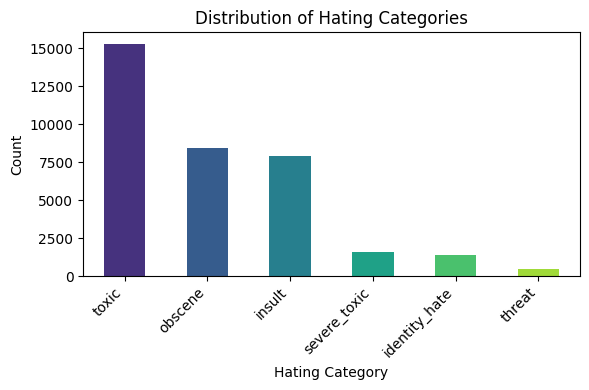

In [28]:
class_counts = y_hate_type.sum().sort_values(ascending=False)

plt.figure(figsize=(6, 4))
class_counts.plot(kind='bar', color=sns.color_palette('viridis', len(class_counts)))
plt.title('Distribution of Hating Categories')
plt.xlabel('Hating Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

A marked class imbalance is evident across the hate-type labels. To address this, the training procedure mirrors the binary case, but the loss function is adapted to the multi-label setting. In particular, a custom multilabel binary loss is employed to handle independent per-class predictions while mitigating the effects of skewed label distributions.

But first let's split the dataset

In [29]:
x_train_hate_type, x_test_hate_type, y_train_hate_type, y_test_hate_type = train_test_split(x_hate_type ,y_hate_type, test_size = 0.2, random_state = 1, shuffle = True)

The overall procedure closely mirrors that of the binary classifier. For this reason, only the steps and considerations specific to the multi-label setting are discussed in detail here, while the common components are not commented again.

In [30]:
num_words_ht = 10000

tokenizer_hate_type = Tokenizer(num_words=num_words_ht, oov_token="<OOV>")
tokenizer_hate_type.fit_on_texts(x_train_hate_type)
print(f'\033[92mNumber of processed commiserations: {tokenizer_hate_type.document_count}\033[0m')

train_hate_type_sequences = tokenizer_hate_type.texts_to_sequences(x_train_hate_type)
test_hate_type_sequences = tokenizer_hate_type.texts_to_sequences(x_test_hate_type)

max_len_hate_type = int(np.percentile([len(seq) for seq in train_hate_type_sequences], 95))
print(f'\033[92mMaximum train sequence length: {max_len_hate_type}\033[0m')

vocabulary_size_hate_type = num_words_ht + 1
print(f'\033[92mVocabulary size: {vocabulary_size_hate_type}\033[0m')


Number of processed commiserations: 12980
Maximum train sequence length: 177
Vocabulary size: 10001


In [31]:
padded_train_hate_type_sequences = pad_sequences(sequences = train_hate_type_sequences, maxlen = max_len_hate_type)
padded_test_hate_type_sequences = pad_sequences(sequences = test_hate_type_sequences, maxlen = max_len_hate_type)

The architecture selected for this model replicates the structure used in the binary classifier. Empirical experimentation confirmed that this configuration also delivers the best performance in the multi-label setting, with more complex alternatives providing no meaningful improvements.

In [54]:
def hate_type_model(vocabulary_size, max_len, dropout, optimizer, loss, metrics,
                      lstm_units=32, embedding_dim=64, dense_units=16):

  model = Sequential()
  model.add(Embedding(input_dim = vocabulary_size, output_dim = embedding_dim, input_length = max_len))

  model.add(Bidirectional(LSTM(lstm_units, return_sequences=False, activation='tanh')))
  model.add(BatchNormalization())
  model.add(Dropout(dropout))

  model.add(Dense(dense_units, activation='relu'))
  model.add(BatchNormalization())
  model.add(Dropout(dropout))

  model.add(Dense(units = 6, activation = 'sigmoid'))
  model.build(input_shape = (None, max_len))

  model.compile(optimizer = optimizer,
                loss = loss,
                metrics = metrics)

  return model

In [55]:
def callback_hate_type_optuna():

  reduce_learning_rate = ReduceLROnPlateau(monitor = 'val_loss',
                                           factor = 0.8,
                                           patience = 2,
                                           min_lr = 1e-6,
                                           verbose = 0)

  early_stop = EarlyStopping(monitor = 'val_loss',
                             patience = 3,
                             restore_best_weights = True,
                             verbose = 1)

  return early_stop, reduce_learning_rate

Determine the weight of the classes

In [56]:
def compute_class_weights(y_train):

  class_counts = np.sum(y_train, axis=0)
  class_freq = class_counts / y_train.shape[0]

  weights = 1.0 / class_freq
  weights = weights / np.sum(weights) * len(weights)

  return weights

weights_tensor = compute_class_weights(y_train_hate_type)

To handle class imbalance in the multi-label setting, a weighted binary cross-entropy loss is defined. This function applies a distinct weight to each class when computing the binary cross-entropy, ensuring that underrepresented labels contribute proportionally more to the overall loss.

In [57]:
def weighted_binary_crossentropy(weights):

  weights = tf.constant(weights, dtype=tf.float32)

  def loss(y_true, y_pred):
    bce = tf.keras.backend.binary_crossentropy(y_true, y_pred)
    return tf.reduce_mean(bce * weights, axis=-1)

  return loss

In [68]:
def objective_ht(trial):

  # HYPERPARAMETERS
  embedding_dim = trial.suggest_categorical("embedding_dim", [128, 256, 512])
  lstm_units = trial.suggest_categorical("lstm_units", [64, 128, 256, 512])
  dropout = trial.suggest_float("dropout", 0.1, 0.5)
  dense_units = trial.suggest_categorical("dense_units", [24, 32, 64, 96])

  learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True)
  batch_size = trial.suggest_categorical("batch_size", [ 128, 256, 512])

  if lstm_units > embedding_dim:
    raise optuna.TrialPruned("LSTM units must be < embedding dim")
  elif dense_units >= lstm_units:
    raise optuna.TrialPruned("Dense units must be <= LSTM units")

  # OPTIMIZER
  optimizer = tf.keras.optimizers.AdamW(learning_rate=learning_rate)

  # MODEL
  model = hate_type_model(
    vocabulary_size = vocabulary_size_hate_type,
    max_len = max_len_hate_type,
    dropout = dropout,
    lstm_units = lstm_units,
    embedding_dim = embedding_dim,
    dense_units = dense_units,
    optimizer=optimizer,
    loss = weighted_binary_crossentropy(weights_tensor),
    metrics = [
      'accuracy',
      tf.keras.metrics.AUC(name = 'auc', multi_label=True),
      tf.keras.metrics.Precision(name = 'precision'),
      tf.keras.metrics.Recall(name = 'recall'),
      F1Score(name='f1')
      ]
  )

  # FIT
  history = model.fit(
      padded_train_hate_type_sequences,
      y_train_hate_type,
      validation_split = 0.2,
      epochs=10,
      batch_size = batch_size,
      callbacks=[callback_hate_type_optuna()]
  )

  # PREDICTION
  y_pred_test = model.predict(padded_test_hate_type_sequences)

  # F1 SCORE EVALUATION ON TEST SET
  f1_test = f1_score(y_test_hate_type, y_pred_test>=0.5, average='micro')
  print(f"Trial {trial.number} — F1 test (not used for tuning): {f1_test:.4f}")

  # GOAL
  val_loss = min(history.history["val_loss"])

  return val_loss


In [69]:
study_ht = optuna.create_study(
        direction="minimize",
        study_name="hate_type_opt",
        sampler=optuna.samplers.TPESampler(seed=42)
    )

study_ht.optimize(objective_ht, n_trials=20)

print(study_ht.best_params)
print(f"\033[92mBest val_loss Score: {study_ht.best_value:.4f}\033[0m")

[I 2025-12-12 09:49:28,201] A new study created in memory with name: hate_type_opt
[I 2025-12-12 09:49:28,204] Trial 0 pruned. Dense units must be <= LSTM units


Epoch 1/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - accuracy: 0.2062 - auc: 0.5352 - f1: 0.4561 - loss: 0.7601 - precision: 0.3991 - recall: 0.5325 - val_accuracy: 0.9391 - val_auc: 0.6128 - val_f1: 0.7030 - val_loss: 0.5089 - val_precision: 0.7209 - val_recall: 0.6859 - learning_rate: 0.0023
Epoch 2/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.4719 - auc: 0.6597 - f1: 0.6075 - loss: 0.4973 - precision: 0.6160 - recall: 0.5993 - val_accuracy: 0.9395 - val_auc: 0.6915 - val_f1: 0.7073 - val_loss: 0.3124 - val_precision: 0.7438 - val_recall: 0.6743 - learning_rate: 0.0023
Epoch 3/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.7128 - auc: 0.7441 - f1: 0.7588 - loss: 0.3165 - precision: 0.7951 - recall: 0.7256 - val_accuracy: 0.9414 - val_auc: 0.6850 - val_f1: 0.6923 - val_loss: 0.2309 - val_precision: 0.9134 - val_recall: 0.5574 - learning_rate: 0.0023
Epoch 4/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.8144 - auc: 0.7995 - f1: 0.7946 - loss: 0.2027 - p

[I 2025-12-12 09:49:47,250] Trial 1 finished with value: 0.21206547319889069 and parameters: {'embedding_dim': 256, 'lstm_units': 128, 'dropout': 0.2465447373174767, 'dense_units': 32, 'learning_rate': 0.00234238498471129, 'batch_size': 256}. Best is trial 1 with value: 0.21206547319889069.
[I 2025-12-12 09:49:47,252] Trial 2 pruned. Dense units must be <= LSTM units


Trial 1 — F1 test (not used for tuning): 0.7608
Epoch 1/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - accuracy: 0.1889 - auc: 0.5126 - f1: 0.4363 - loss: 0.9061 - precision: 0.3759 - recall: 0.5197 - val_accuracy: 0.9411 - val_auc: 0.5561 - val_f1: 0.7372 - val_loss: 0.6747 - val_precision: 0.6245 - val_recall: 0.8997 - learning_rate: 3.5868e-04
Epoch 2/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.2269 - auc: 0.5549 - f1: 0.4734 - loss: 0.7654 - precision: 0.4123 - recall: 0.5560 - val_accuracy: 0.9322 - val_auc: 0.5817 - val_f1: 0.6722 - val_loss: 0.6215 - val_precision: 0.6475 - val_recall: 0.6988 - learning_rate: 3.5868e-04
Epoch 3/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.2626 - auc: 0.5832 - f1: 0.4972 - loss: 0.6907 - precision: 0.4432 - recall: 0.5664 - val_accuracy: 0.9418 - val_auc: 0.5886 - val_f1: 0.7007 - val_loss: 0.5503 - val_precision: 0.7182 - val_recall: 0.6841 - learning_rate: 3.5868e-04
Epoch 4/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - ac

[I 2025-12-12 09:50:13,306] Trial 3 finished with value: 0.2478104531764984 and parameters: {'embedding_dim': 512, 'lstm_units': 128, 'dropout': 0.4687496940092467, 'dense_units': 96, 'learning_rate': 0.00035868164986275477, 'batch_size': 256}. Best is trial 1 with value: 0.21206547319889069.


...

Trial 16 — F1 test (not used for tuning): 0.7704
Epoch 1/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.1785 - auc: 0.5233 - f1: 0.4387 - loss: 0.7762 - precision: 0.3800 - recall: 0.5190 - val_accuracy: 0.8686 - val_auc: 0.5880 - val_f1: 0.5754 - val_loss: 0.6606 - val_precision: 0.4978 - val_recall: 0.6818 - learning_rate: 4.2923e-04
Epoch 2/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.2237 - auc: 0.6139 - f1: 0.4914 - loss: 0.6734 - precision: 0.4443 - recall: 0.5498 - val_accuracy: 0.0327 - val_auc: 0.6592 - val_f1: 0.4265 - val_loss: 0.5694 - val_precision: 0.5521 - val_recall: 0.3474 - learning_rate: 4.2923e-04
Epoch 3/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.2754 - auc: 0.7056 - f1: 0.5576 - loss: 0.6195 - precision: 0.5233 - recall: 0.5968 - val_accuracy: 0.0327 - val_auc: 0.7366 - val_f1: 0.3757 - val_loss: 0.5126 - val_precision: 0.5548 - val_recall: 0.2840 - learning_rate: 4.2923e-04
Epoch 4/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - a

[I 2025-12-12 09:54:14,606] Trial 17 finished with value: 0.28203609585762024 and parameters: {'embedding_dim': 256, 'lstm_units': 256, 'dropout': 0.15902529132314963, 'dense_units': 32, 'learning_rate': 0.000429230113641653, 'batch_size': 256}. Best is trial 16 with value: 0.19807539880275726.
[I 2025-12-12 09:54:14,615] Trial 18 pruned. LSTM units must be < embedding dim


Trial 17 — F1 test (not used for tuning): 0.7684
Epoch 1/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.1544 - auc: 0.5507 - f1: 0.4536 - loss: 0.7582 - precision: 0.3985 - recall: 0.5266 - val_accuracy: 0.0616 - val_auc: 0.5969 - val_f1: 0.7508 - val_loss: 0.5642 - val_precision: 0.6525 - val_recall: 0.8839 - learning_rate: 8.4455e-04
Epoch 2/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.2982 - auc: 0.6892 - f1: 0.5715 - loss: 0.5710 - precision: 0.5676 - recall: 0.5758 - val_accuracy: 0.9407 - val_auc: 0.6862 - val_f1: 0.6298 - val_loss: 0.4388 - val_precision: 0.9364 - val_recall: 0.4745 - learning_rate: 8.4455e-04
Epoch 3/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.5359 - auc: 0.7602 - f1: 0.6932 - loss: 0.4362 - precision: 0.7300 - recall: 0.6599 - val_accuracy: 0.9337 - val_auc: 0.7110 - val_f1: 0.7068 - val_loss: 0.3319 - val_precision: 0.9325 - val_recall: 0.5691 - learning_rate: 8.4455e-04
Epoch 4/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - a

[I 2025-12-12 09:54:45,925] Trial 19 finished with value: 0.1818469613790512 and parameters: {'embedding_dim': 512, 'lstm_units': 64, 'dropout': 0.2548022344856538, 'dense_units': 24, 'learning_rate': 0.0008445502224517828, 'batch_size': 128}. Best is trial 19 with value: 0.1818469613790512.


Trial 19 — F1 test (not used for tuning): 0.7796
{'embedding_dim': 512, 'lstm_units': 64, 'dropout': 0.2548022344856538, 'dense_units': 24, 'learning_rate': 0.0008445502224517828, 'batch_size': 128}
Best val_loss Score: 0.1818


Now we define the callback for training

In [62]:
def callback_hate_type():

  reduce_learning_rate = ReduceLROnPlateau(monitor = 'val_loss',
                                           factor = 0.8,
                                           patience = 3,
                                           min_lr = 1e-6,
                                           verbose = 0)

  early_stop = EarlyStopping(monitor = 'val_loss',
                             patience = 7,
                             restore_best_weights = True,
                             verbose = 1)

  return early_stop, reduce_learning_rate

In [64]:
clear_session()
model_ht = hate_type_model(
    vocabulary_size = vocabulary_size_hate_type,
    max_len = max_len_hate_type,
    dropout = study_ht.best_params['dropout'],
    lstm_units = study_ht.best_params['lstm_units'],
    embedding_dim = study_ht.best_params['embedding_dim'],
    dense_units = study_ht.best_params['dense_units'],
    optimizer = tf.keras.optimizers.AdamW(learning_rate = study_ht.best_params['learning_rate']),
    loss = weighted_binary_crossentropy(weights_tensor),
    metrics = [
      'accuracy',
      tf.keras.metrics.AUC(name = 'auc', multi_label=True),
      tf.keras.metrics.Precision(name = 'precision'),
      tf.keras.metrics.Recall(name = 'recall'),
      F1Score(name='f1')
      ]
  )
model_ht.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 177, 512)       │     5,120,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       656,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,795,014 (22.11 MB)

 Trainable params: 5,794,374 (22.10 MB)

 Non-trainable params: 640 (2.50 KB)

Finally the model is fitted

In [71]:
history_hate_type = model_ht.fit(padded_train_hate_type_sequences,
                                        y_train_hate_type,
                                        epochs = 100,
                                        validation_split = 0.2,
                                        batch_size = study_ht.best_params['batch_size'],
                                        callbacks = [callback_hate_type()])

Epoch 1/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.7741 - auc: 0.9009 - f1: 0.8934 - loss: 0.0774 - precision: 0.8925 - recall: 0.8943 - val_accuracy: 0.8109 - val_auc: 0.7353 - val_f1: 0.7781 - val_loss: 0.2105 - val_precision: 0.7812 - val_recall: 0.7750 - learning_rate: 2.5715e-04
Epoch 2/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.7721 - auc: 0.9110 - f1: 0.8999 - loss: 0.0696 - precision: 0.8970 - recall: 0.9029 - val_accuracy: 0.8910 - val_auc: 0.7363 - val_f1: 0.7753 - val_loss: 0.2190 - val_precision: 0.8228 - val_recall: 0.7330 - learning_rate: 2.5715e-04
Epoch 3/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.7701 - auc: 0.9199 - f1: 0.9052 - loss: 0.0661 - precision: 0.9048 - recall: 0.9056 - val_accuracy: 0.8952 - val_auc: 0.7363 - val_f1: 0.7733 - val_loss: 0.2278 - val_precision: 0.8178 - val_recall: 0.7334 - learning_rate: 2.5715e-04
Epoch 4/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.7692 - auc: 0.9267 - f1: 0.9091 - 

In [73]:
evaluation_ht = model_ht.evaluate(padded_test_hate_type_sequences, y_test_hate_type)

102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8226 - auc: 0.7270 - f1: 0.7773 - loss: 0.2496 - precision: 0.7867 - recall: 0.7683


The multi-label hate-type model was evaluated on the held-out test set. The performance metrics obtained are as follows:

- Accuracy: 0.823

- AUC: 0.727

- F1-score: 0.777

- Precision: 0.787

- Recall: 0.768

- Loss: 0.2496

These results indicate that the model maintains strong overall predictive capability while effectively capturing multiple hate-type categories simultaneously. The F1-score, in particular, reflects a good balance between precision and recall across the highly imbalanced labels.

In multi-label classification, the optimal threshold for each class can differ due to class imbalance and varying prediction distributions. To maximize the F1-score per label, we compute label-specific thresholds using the precision-recall curve on the test set.

The following function calculates the threshold that maximizes F1 for each hate-type category:

In [90]:
def f1_score_optimization_thresholds_ht(y_true, y_pred, labels):
  y_true = np.array(y_true)
  optimal_thresholds = {}

  for i, label in enumerate(labels):
    precision, recall, thresholds = precision_recall_curve(y_true[:, i], y_pred[:, i])
    f1_scores = (2 * precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1])
    f1_scores[np.isnan(f1_scores)] = 0

    optimal_threshold = float(thresholds[np.argmax(f1_scores)])
    optimal_thresholds[label] = optimal_threshold

  return optimal_thresholds


We then apply this function to determine the thresholds for each label:

In [91]:
optimal_thresholds_ht = f1_score_optimization_thresholds_ht(
    y_true = y_test_hate_type,
    y_pred = model_ht.predict(padded_test_hate_type_sequences),
    labels = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
    )

optimal_thresholds_ht

102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


{'toxic': 0.7201123833656311,
 'severe_toxic': 0.4271005392074585,
 'obscene': 0.49723517894744873,
 'threat': 0.054385628551244736,
 'insult': 0.23478339612483978,
 'identity_hate': 0.07636448740959167}

This approach ensures that each label is evaluated using a threshold that maximizes its F1-score, improving overall multi-label performance compared to a fixed threshold of 0.5.

# Inference

A utility function `predict_text` is defined to perform end-to-end inference on a single input comment. The procedure follows the two-stage pipeline established during training:

Data preprocessing: the input text is cleaned using the same `clean` function applied to the training set.

Binary classification: the text is tokenized and padded, then passed to the trained binary hate model. A probability above the optimized threshold classifies the comment as hateful `(1)` or not `(0)`.

If the comment is predicted as non-hateful, the function returns a zero vector across all hate-type labels.

Multi-label classification: if the comment is hateful, it is tokenized and padded for the hate-type model. Each class probability is compared against its corresponding optimal threshold to produce a binary vector representing the presence of each hate-type category.

The output is a list of integers corresponding to `[toxic, severe_toxic, obscene, threat, insult, identity_hate]`.

In [98]:
def predict_text(text, verbose=True):

  # DATA CLEANING
  text = clean(text)

  # FIRST MODEL (binary hate)
  seq = tokenizer_binary_hate.texts_to_sequences([text])
  pad = pad_sequences(seq, maxlen = max_len_binary_hate)
  prob = model_hate_binary.predict(pad, verbose = False)[0][0]

  pred = int(prob >= optimal_thresholds_bh['has_hate'])

  if pred == 0:
    return [0,0,0,0,0,0]

  # SECOND MODEL (hate type)
  seq = tokenizer_hate_type.texts_to_sequences([text])
  pad = pad_sequences(seq, maxlen = max_len_hate_type)
  probs = model_ht.predict(pad, verbose = False)[0]

  labels = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
  outputs = [
    int(probs[i] >= optimal_thresholds_ht[f"{label}"])
    for i, label in enumerate(labels)
  ]

  return outputs

Finally, a simple interactive loop allows the user to input arbitrary sentences and obtain model predictions in real time. Typing "exit" terminates the session

In [104]:
while True:
  text = input("Write a sentence ('exit' for to go out): ")
  if text == "exit": break

  result = predict_text(text)
  print(result)

Write a sentence ('exit' for to go out): Nigga go away
[1, 0, 1, 0, 1, 1]
Write a sentence ('exit' for to go out): Your opinion doesn't matter, shut up
[1, 0, 0, 0, 0, 0]
Write a sentence ('exit' for to go out): This morning I had breakfast with Marco
[1, 0, 0, 0, 0, 0]
Write a sentence ('exit' for to go out): Fuck you asshole
[1, 0, 1, 0, 1, 0]
Write a sentence ('exit' for to go out): I have a cat named Emy, if only you could see how beautiful she is
[0, 0, 0, 0, 0, 0]
Write a sentence ('exit' for to go out): exit


This interface leverages the trained model to perform live inference on single comments, demonstrating its practical usage.